In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Read the CSV File
customers = pd.read_csv('customers.csv')
stores = pd.read_csv('stores.csv')
products = pd.read_csv('products.csv')
sales = pd.read_csv('sales_data.csv')
returns = pd.read_csv('returns.csv')

(816, 7)
Index(['customer_id', 'first_name', 'last_name', 'gender', 'age',
       'signup_date', 'region'],
      dtype='object')
(61, 6)
Customers missing values:
 customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64

Stores missing values:
 store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64

Products missing values:
 product_id       0
product_name     0
category         0
brand           60
cost_price       0
unit_price       0
margin_pct       0
dtype: int64

Sales missing values:
 order_id           0
order_date         0
customer_id        0
product_id         0
store_id         992
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64

Returns missing values:
 return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64
Cus

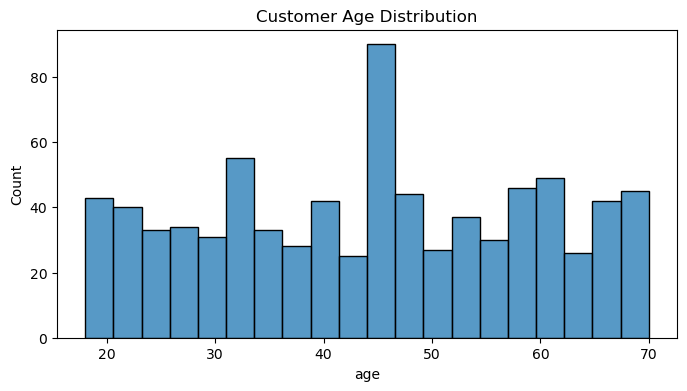

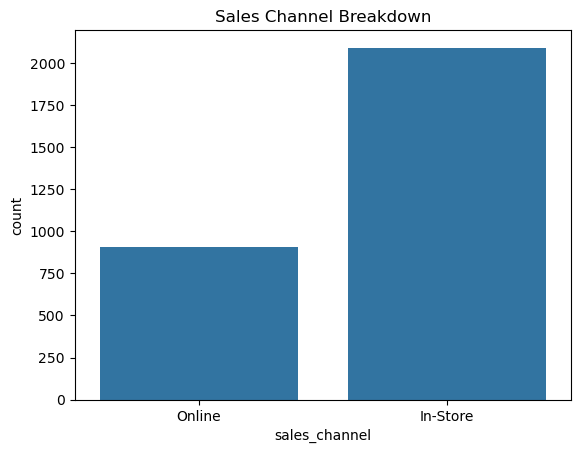

0


In [ ]:
#Initial Data Overview
## Get the shape and column info
print(customers.shape)
print(customers.columns)
customers.head()

print(stores.shape)
stores.head()

#Check for Missing Values
print("Customers missing values:\n", customers.isnull().sum())
print("\nStores missing values:\n", stores.isnull().sum())
print("\nProducts missing values:\n", products.isnull().sum())
print("\nSales missing values:\n", sales.isnull().sum())
print("\nReturns missing values:\n", returns.isnull().sum())

#Remove Duplicates
customers = customers.drop_duplicates()
stores = stores.drop_duplicates()
products = products.drop_duplicates()
sales = sales.drop_duplicates()
returns = returns.drop_duplicates()

# View how many rows after duplicate removal
print("Customers rows after cleaning:", customers.shape[0])
print("Stores rows after cleaning:", stores.shape[0])
print("Products rows after cleaning:", products.shape[0])
print("Sales rows after cleaning:", sales.shape[0])
print("Returns rows after cleaning:", returns.shape[0])

#Data Types and Conversion
sales['order_date'] = pd.to_datetime(sales['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])


# Fill missing values
customers['age'] = customers['age'].fillna(customers['age'].mean())
products['brand'] = products['brand'].fillna('Unknown')
sales['store_id'] = sales['store_id'].fillna('Online')


# Exploratory Data Analysis (EDA)
#Summary Statistics
print(customers.describe())
print(stores.describe())
print(products.describe())
print(sales.describe())
print(returns.describe())

#count of each unique value in those columns
print(customers['gender'].value_counts())
print(stores['region'].value_counts())
print(products['category'].value_counts())
print(sales['sales_channel'].value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

# Customer Age Distribution
plt.figure(figsize=(8,4))
sns.histplot(customers['age'], bins=20)
plt.title('Customer Age Distribution')
plt.show()

# Sales by Channel
sns.countplot(x=sales['sales_channel'])
plt.title('Sales Channel Breakdown')
plt.show()

#Count of Sales Transactions with Unknown Customer IDs
print(sales[~sales['customer_id'].isin(customers['customer_id'])].shape[0])


#Derived Coloumn
customers['age_group'] = pd.cut(customers['age'], bins=[0,25,40,55,100], labels=['Young','Adult','Mature','Senior'])

#Profit per Sale (in sales data)
# Merge sales and products for cost price
sales = sales.merge(products[['product_id', 'cost_price']], on='product_id', how='left')
sales['profit'] = (sales['unit_price'] - sales['cost_price']) * sales['quantity'] * (1 - sales['discount_pct'])


#Customer Tenure (days since signup)
#How long the customer has been with the company:
customers['tenure_days'] = (pd.Timestamp.today() - customers['signup_date']).dt.days


# Return Flag (was this sale returned?)
sales['is_returned'] = sales['order_id'].isin(returns['order_id']).astype(int)


#Order Month/Year (for time-based analysis)
sales['order_month'] = sales['order_date'].dt.to_period('M')
sales['order_year'] = sales['order_date'].dt.year


#to save cleaned DataFrames
customers.to_csv('customers_cleaned.csv', index=False)
stores.to_csv('stores_cleaned.csv', index=False)
products.to_csv('products_cleaned.csv', index=False)
returns.to_csv('returns_cleaned.csv', index=False)
df.to_csv('sales_data_fixed.csv', index=False)

In [9]:
import os
print(os.getcwd())

C:\Users\Abhinav


In [15]:
sales = pd.read_csv(r"C:/Users/Abhinav/Desktop/sales_cleaned_no_online.csv")